# Content-Based Filtering with Sentence Embeddings

**Dataset:** HetRec 2011 MovieLens 2K  
**Methods:** `sentence-transformers` (all-MiniLM-L6-v2) · SHAP · LIME · MLflow

---

**Goal:** Instead of sparse TF-IDF vectors, we represent each movie as a dense 384-dimensional embedding produced by a pre-trained BERT-based model. Two movies with similar genres, directors, actors, and tags will have embeddings that are geometrically close — their cosine similarity will be high.

| Step | What we do |
|------|------------|
| 1 | Imports |
| 2 | Load the data |
| 3 | Build movie content profiles |
| 4 | Generate sentence embeddings |
| 5 | Movie-to-movie recommendations |
| 6 | User-based recommendations |
| 7 | Explainability — SHAP |
| 8 | Explainability — LIME |
| 9 | Evaluation (Precision@K, Coverage, Diversity) |
| 10 | Visualisations (heatmap + t-SNE) |
| 11 | Save outputs |
| 12 | Experiment tracking — MLflow |

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE

from sentence_transformers import SentenceTransformer
import shap
from lime import lime_text
import mlflow

import warnings
warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.dpi'] = 110

print('All imports OK')

All imports OK


## Step 2 — Load the Data

We use the same seven `.dat` files as in the baseline notebook.

In [2]:
DATA_PATH = '../data/raw/'

movies = pd.read_csv(
    DATA_PATH + 'movies.dat', sep='\t', encoding='latin-1',
    usecols=[0, 1, 5],
    names=['movieID','title','imdbID','spanishTitle','imdbPictureURL',
           'year','rtID','rtAllCriticsRating','rtAllCriticsNumReviews',
           'rtAllCriticsNumFresh','rtAllCriticsNumRotten','rtAllCriticsScore',
           'rtTopCriticsRating','rtTopCriticsNumReviews','rtTopCriticsNumFresh',
           'rtTopCriticsNumRotten','rtTopCriticsScore','rtAudienceRating',
           'rtAudienceNumRatings','rtAudienceScore','rtPictureURL'],
    header=0
)

movie_genres = pd.read_csv(
    DATA_PATH + 'movie_genres.dat', sep='\t', encoding='latin-1',
    header=0, names=['movieID','genre']
)

movie_directors = pd.read_csv(
    DATA_PATH + 'movie_directors.dat', sep='\t', encoding='latin-1',
    header=0, names=['movieID','directorID','directorName']
)

movie_actors = pd.read_csv(
    DATA_PATH + 'movie_actors.dat', sep='\t', encoding='latin-1',
    header=0, names=['movieID','actorID','actorName','ranking']
)

movie_tags = pd.read_csv(
    DATA_PATH + 'movie_tags.dat', sep='\t', encoding='latin-1',
    header=0, names=['movieID','tagID','tagWeight']
)

tags = pd.read_csv(
    DATA_PATH + 'tags.dat', sep='\t', encoding='latin-1',
    header=0, names=['tagID','tagValue']
)

ratings = pd.read_csv(
    DATA_PATH + 'user_ratedmovies.dat', sep='\t', encoding='latin-1',
    header=0, usecols=[0,1,2],
    names=['userID','movieID','rating','date_day','date_month',
           'date_year','date_hour','date_minute','date_second']
)

print(f'Movies:    {len(movies):>7,}')
print(f'Genres:    {len(movie_genres):>7,}')
print(f'Directors: {len(movie_directors):>7,}')
print(f'Actors:    {len(movie_actors):>7,}')
print(f'Tags:      {len(movie_tags):>7,}')
print(f'Ratings:   {len(ratings):>7,}')

Movies:     10,197
Genres:     20,809
Directors:  10,155
Actors:    231,742
Tags:       51,795
Ratings:   855,598


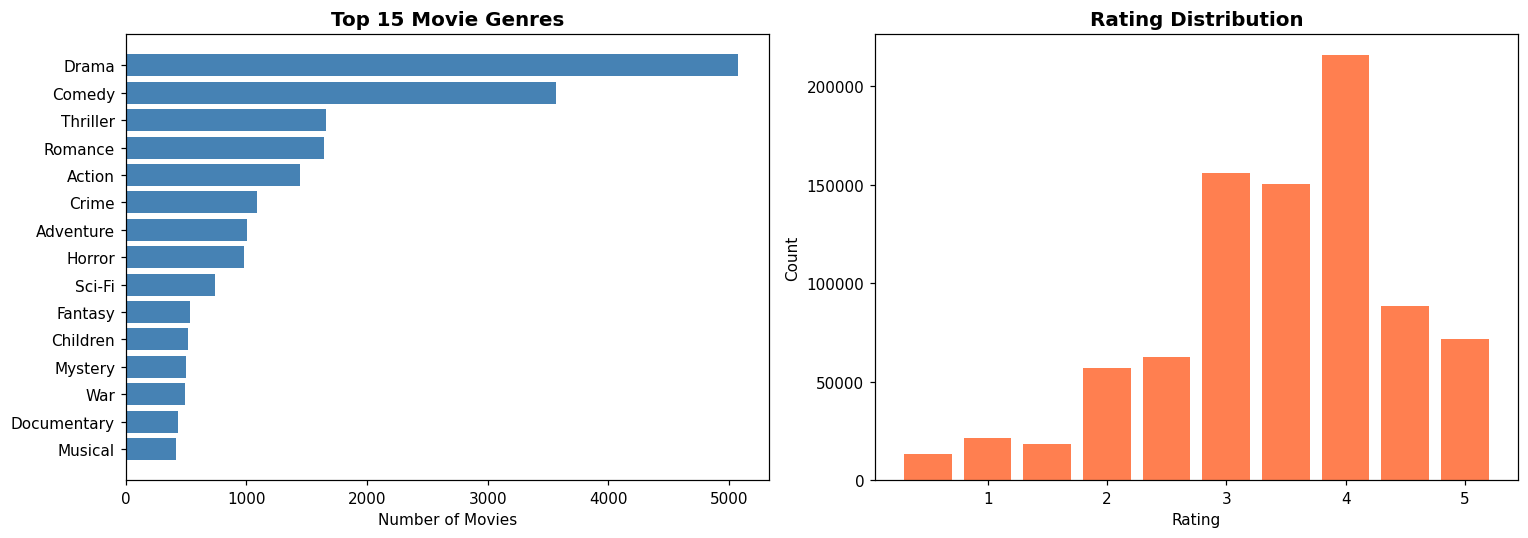

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts = movie_genres['genre'].value_counts().head(15)
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Movie Genres', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Movies')

rating_counts = ratings['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='coral', width=0.4)
axes[1].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 3 — Build Movie Content Profiles

Each movie gets a single text string (`content_soup`) combining all its metadata:

```
"Animation Adventure Children ... john_lasseter tom_hanks ... pixar disney toys ..."
```

Genres are repeated twice to give them extra weight.

In [4]:
# Genres per movie
genres_grouped = (
    movie_genres
    .groupby('movieID')['genre']
    .apply(lambda x: ' '.join(x.str.replace(' ', '_')))
    .reset_index()
    .rename(columns={'genre': 'genres_str'})
)

# Director per movie
director_grouped = (
    movie_directors
    .groupby('movieID')['directorName']
    .first()
    .reset_index()
)
director_grouped['directorName'] = (
    director_grouped['directorName'].str.replace(' ', '_').str.lower()
)

# Top-5 actors per movie
top_actors = (
    movie_actors[movie_actors['ranking'] <= 5]
    .groupby('movieID')['actorName']
    .apply(lambda x: ' '.join(x.str.replace(' ', '_').str.lower()))
    .reset_index()
    .rename(columns={'actorName': 'actors_str'})
)

# Top-10 tags per movie (by weight)
movie_tags_named = movie_tags.merge(tags, on='tagID', how='left')
top_tags = (
    movie_tags_named
    .sort_values(['movieID','tagWeight'], ascending=[True,False])
    .groupby('movieID').head(10)
    .groupby('movieID')['tagValue']
    .apply(lambda x: ' '.join(x.astype(str).str.replace(' ', '_').str.lower()))
    .reset_index()
    .rename(columns={'tagValue': 'tags_str'})
)

# Merge into one profile per movie
movie_profiles = movies[['movieID','title','year']].copy()
movie_profiles = movie_profiles.merge(genres_grouped, on='movieID', how='left')
movie_profiles = movie_profiles.merge(director_grouped, on='movieID', how='left')
movie_profiles = movie_profiles.merge(top_actors, on='movieID', how='left')
movie_profiles = movie_profiles.merge(top_tags, on='movieID', how='left')

for col in ['genres_str','directorName','actors_str','tags_str']:
    movie_profiles[col] = movie_profiles[col].fillna('')

# content_soup: genres doubled for extra weight
movie_profiles['content_soup'] = (
    movie_profiles['genres_str'] + ' ' +
    movie_profiles['genres_str'] + ' ' +
    movie_profiles['directorName'] + ' ' +
    movie_profiles['actors_str'] + ' ' +
    movie_profiles['tags_str']
).str.strip()

# Remove empty profiles
movie_profiles_clean = movie_profiles[movie_profiles['content_soup'].str.len() > 0].copy()
movie_profiles_clean = movie_profiles_clean.reset_index(drop=True)

print(f'Movies with profiles: {len(movie_profiles_clean)}')
print()
ex = movie_profiles_clean.iloc[0]
print(f"Title: {ex['title']}")
print(f"Soup:  {ex['content_soup'][:180]}...")

Movies with profiles: 10197

Title: Toy story
Soup:  Adventure Animation Children Comedy Fantasy Adventure Animation Children Comedy Fantasy john_lasseter don_rickles jim_varney tim_allen tom_hanks wallace_shawn animation pixar disne...


## Step 4 — Generate Sentence Embeddings

We encode every movie's `content_soup` with **`all-MiniLM-L6-v2`** — a lightweight but accurate BERT-based model that produces 384-dimensional dense vectors.

- Embeddings are **L2-normalised** so cosine similarity = dot product.
- Results are cached to disk so encoding only runs once.

In [6]:
CACHE = Path('../data/processed/movie_embeddings.npy')
Path('../data/processed').mkdir(parents=True, exist_ok=True)

if CACHE.exists():
    embeddings = np.load(CACHE)
    print(f'Loaded from cache — shape: {embeddings.shape}')
else:
    print('Encoding with all-MiniLM-L6-v2 (first run only, ~1-2 min)...')
    st_model = SentenceTransformer('all-MiniLM-L6-v2')
    soups = movie_profiles_clean['content_soup'].tolist()
    embeddings = st_model.encode(soups, show_progress_bar=True, batch_size=64)
    # L2 normalise so dot product = cosine similarity
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / np.maximum(norms, 1e-9)
    np.save(CACHE, embeddings)
    print(f'Saved — shape: {embeddings.shape}')

print(f'\nEmbedding shape: {embeddings.shape}')   # (10197, 384)
print(f'Each vector is L2-normalised: norm = {np.linalg.norm(embeddings[0]):.4f}')

Loaded from cache — shape: (10197, 384)

Embedding shape: (10197, 384)
Each vector is L2-normalised: norm = 1.0000


## Step 5 — Movie-to-Movie Recommendations

Because the embeddings are L2-normalised, cosine similarity is just a dot product:

```python
scores = embeddings @ embeddings[query_idx]   # fast, no sklearn needed
```

In [7]:
# Map movie title -> row index in movie_profiles_clean (and embeddings).
# Some titles appear multiple times in the dataset (different movieIDs sharing a title);
# we keep only the first occurrence so each title maps to a single integer index.
title_to_index = pd.Series(
    movie_profiles_clean.index.values,
    index=movie_profiles_clean['title']
)
title_to_index = title_to_index[~title_to_index.index.duplicated(keep='first')]

def get_recommendations(movie_title, n=10, verbose=True):
    """
    Return the top-N most similar movies using embedding cosine similarity.
    """
    if movie_title not in title_to_index:
        matches = [t for t in title_to_index.index if movie_title.lower() in t.lower()]
        if matches:
            print(f"'{movie_title}' not found. Did you mean:")
            for m in matches[:5]:
                print(f'  → {m}')
        else:
            print(f"Movie '{movie_title}' not found.")
        return None

    idx    = int(title_to_index[movie_title])
    scores = embeddings @ embeddings[idx]          # cosine similarity to all movies
    top_n  = np.argsort(scores)[::-1][1:n+1]      # skip self (rank 0)

    result = movie_profiles_clean[['title','year','genres_str']].iloc[top_n].copy()
    result['similarity'] = np.round(scores[top_n], 4)
    result.index = range(1, n+1)

    if verbose:
        src = movie_profiles_clean.iloc[idx]
        print(f"\nBecause you liked: '{movie_title}' ({int(src['year'])})")
        print(f"Genres: {src['genres_str']}")
        print()
        print(f"Top {n} recommendations:")
        print('-' * 65)
        print(f"{'#':<4} {'Title':<40} {'Year':<6} Similarity")
        print('-' * 65)
        for rank, row in result.iterrows():
            print(f"{rank:<4} {str(row['title'])[:39]:<40} {str(int(row['year'])):<6} {row['similarity']:.4f}")
        print('-' * 65)

    return result

print('Recommendation function defined!')

Recommendation function defined!


In [8]:
_ = get_recommendations('Toy story', n=10)


Because you liked: 'Toy story' (1995)
Genres: Adventure Animation Children Comedy Fantasy

Top 10 recommendations:
-----------------------------------------------------------------
#    Title                                    Year   Similarity
-----------------------------------------------------------------
1    Toy Story                                1995   0.9175
2    Cars                                     2006   0.8459
3    A Bug's Life                             1998   0.8399
4    Chicken Little                           2005   0.8354
5    The Polar Express                        2004   0.8237
6    Monsters, Inc.                           2001   0.8237
7    Monster House                            2006   0.8211
8    The Wild                                 2006   0.8208
9    The Lion King                            1994   0.8139
10   Brother Bear                             2003   0.8138
-----------------------------------------------------------------


In [9]:
_ = get_recommendations('The Matrix', n=10)


Because you liked: 'The Matrix' (1999)
Genres: Action Sci-Fi Thriller

Top 10 recommendations:
-----------------------------------------------------------------
#    Title                                    Year   Similarity
-----------------------------------------------------------------
1    The Matrix Reloaded                      2003   0.9285
2    The Matrix Revolutions                   2003   0.8752
3    eXistenZ                                 1999   0.7894
4    Predator                                 1987   0.7667
5    Minority Report                          2002   0.7644
6    Predator                                 1987   0.7635
7    Red Planet                               2000   0.7628
8    Speed                                    1994   0.7548
9    Total Recall                             1990   0.7538
10   RoboCop 2                                1990   0.7504
-----------------------------------------------------------------


In [10]:
_ = get_recommendations('Star Wars', n=10)


Because you liked: 'Star Wars' (1977)
Genres: Action Adventure Sci-Fi

Top 10 recommendations:
-----------------------------------------------------------------
#    Title                                    Year   Similarity
-----------------------------------------------------------------
1    Star Wars: Episode V - The Empire Strik  1980   0.8752
2    Star Wars: Episode VI - Return of the J  1983   0.8555
3    Star Wars: Episode II - Attack of the C  2002   0.8057
4    The Lost World: Jurassic Park            1997   0.7999
5    Indiana Jones and the Temple of Doom     1984   0.7794
6    X-Men                                    2000   0.7673
7    Sky Captain and the World of Tomorrow    2004   0.7624
8    Superman II                              1980   0.7613
9    Star Wars: Episode III - Revenge of the  2005   0.7568
10   Terminator 3: Rise of the Machines       2003   0.7471
-----------------------------------------------------------------


## Step 6 — User-Based Recommendations

**Idea:** average the embeddings of all movies a user rated highly → this gives a *user profile vector* in the same 384-dimensional space. We then find the unseen movies closest to that vector.

In [11]:
def recommend_for_user(user_id, n=10, min_rating=4.0):
    """
    Build a user profile from their highly-rated movies and return top-N recommendations.
    Uses movieID -> row-index lookup directly (avoids duplicate-title issues).
    """
    liked_ids = ratings[
        (ratings['userID'] == user_id) & (ratings['rating'] >= min_rating)
    ]['movieID'].values

    liked_mask = movie_profiles_clean['movieID'].isin(liked_ids)
    liked_idx  = movie_profiles_clean.index[liked_mask].tolist()
    liked_titles = movie_profiles_clean.loc[liked_idx, 'title'].tolist()

    seen_ids = ratings[ratings['userID'] == user_id]['movieID'].values

    if not liked_idx:
        print(f'User {user_id} has no liked movies (rating >= {min_rating}).')
        return None

    # Average embedding of liked movies = user profile
    user_profile = embeddings[liked_idx].mean(axis=0)
    user_profile = user_profile / np.maximum(np.linalg.norm(user_profile), 1e-9)

    scores = embeddings @ user_profile

    # Mask already-seen movies
    seen_mask = movie_profiles_clean['movieID'].isin(seen_ids).values
    scores[seen_mask] = -1.0

    top_n = np.argsort(scores)[::-1][:n]
    result = movie_profiles_clean[['title','year','genres_str']].iloc[top_n].copy()
    result['score'] = np.round(scores[top_n], 4)
    result.index = range(1, n+1)

    print(f"\nUser {user_id} | rated {len(liked_titles)} movies >= {min_rating}★")
    print(f"Sample liked: {liked_titles[:3]}")
    print()
    print(f"Top {n} recommendations:")
    print('-' * 65)
    for rank, row in result.iterrows():
        print(f"{rank:<4} {str(row['title'])[:39]:<40} {str(int(row['year'])):<6} {row['score']:.4f}")
    print('-' * 65)

    return result

print('User recommendation function defined!')

User recommendation function defined!


In [12]:
sample_user = ratings['userID'].sample(1, random_state=SEED).values[0]
_ = recommend_for_user(sample_user, n=10)


User 55468 | rated 243 movies >= 4.0★
Sample liked: ['Toy story', 'Heat', 'Sense and Sensibility']

Top 10 recommendations:
-----------------------------------------------------------------
1    Out of Sight                             1998   0.8429
2    The Mission                              1986   0.8399
3    Live Free or Die Hard                    2007   0.8392
4    Frida                                    2002   0.8383
5    Die fetten Jahre sind vorbei             2004   0.8351
6    Monster's Ball                           2001   0.8319
7    The Last Supper                          1995   0.8319
8    Thelma & Louise                          1991   0.8309
9    This Boy's Life                          1993   0.8293
10   Prizzi's Honor                           1985   0.8268
-----------------------------------------------------------------


## Step 7 — Explainability: SHAP

**Problem:** Sentence embeddings are dense vectors — we cannot directly read which features (genre, actor, director, tag) drove the similarity score.

**Solution:** We train a *surrogate* Random Forest on TF-IDF word features to mimic the embedding similarity, then apply SHAP's `TreeExplainer` to that surrogate. The SHAP values reveal which words (= movie features) push a movie toward or away from the recommendation zone.

This follows exactly the same SHAP workflow from the course (Assignment 2, Problem 2.1).

In [13]:
# --- 7a. Build binary labels ---
# A movie is labelled 1 if it is in the top-100 most similar to the query movie

QUERY = 'Toy story'
query_idx   = title_to_index[QUERY]
sim_scores  = embeddings @ embeddings[query_idx]
threshold   = np.sort(sim_scores)[::-1][100]       # 101st score
y_labels    = (sim_scores >= threshold).astype(int)

print(f'Query movie: "{QUERY}"')
print(f'Positive (similar) movies:  {y_labels.sum()}')
print(f'Negative (rest):            {(y_labels == 0).sum()}')

Query movie: "Toy story"
Positive (similar) movies:  101
Negative (rest):            10096


In [14]:
# --- 7b. TF-IDF features (interpretable word-level) ---
tfidf        = TfidfVectorizer(max_features=2000)
X_tfidf      = tfidf.fit_transform(movie_profiles_clean['content_soup']).toarray()
feature_names = tfidf.get_feature_names_out()

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_labels, test_size=0.2, random_state=SEED, stratify=y_labels
)

# --- 7c. Train surrogate Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test), target_names=['not_similar','similar']))

              precision    recall  f1-score   support

 not_similar       0.99      1.00      1.00      2020
     similar       1.00      0.15      0.26        20

    accuracy                           0.99      2040
   macro avg       1.00      0.57      0.63      2040
weighted avg       0.99      0.99      0.99      2040



In [15]:
# --- 7d. SHAP TreeExplainer ---
# Robust extraction of class-1 SHAP values, works across SHAP versions:
#   - SHAP <  0.41 : returns a list  [array_class0, array_class1]
#   - SHAP >= 0.41 : returns a 3D ndarray (n_samples, n_features, n_classes)
# check_additivity=False bypasses a numerical-precision sanity check that
# can fail with very sparse TF-IDF inputs.
explainer   = shap.TreeExplainer(rf)
X_shap      = X_test[:300]
shap_values = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(shap_values, list):
    sv_c1 = shap_values[1]
elif np.ndim(shap_values) == 3:
    sv_c1 = shap_values[:, :, 1]
else:
    sv_c1 = shap_values   # binary case where API returns 2D directly

ev      = explainer.expected_value
base_c1 = ev[1] if hasattr(ev, '__len__') else float(ev)

X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# Sanity assertion: SHAP values must align with X_shap
assert sv_c1.shape == X_shap_df.shape, (
    f'Shape mismatch: sv_c1={sv_c1.shape}, X_shap_df={X_shap_df.shape}'
)

print(f'sv_c1 (class similar) shape: {sv_c1.shape}')
print(f'X_shap_df shape:             {X_shap_df.shape}')
print(f'Base value (class similar):  {base_c1:.4f}')

sv_c1 (class similar) shape: (300, 2000)
X_shap_df shape:             (300, 2000)
Base value (class similar):  0.0098


### 7.1 — Beeswarm Summary Plot

Each dot = one movie. The x-axis is the SHAP value (positive = pushes toward *similar*). Color = actual feature value (red = high TF-IDF weight, blue = low).

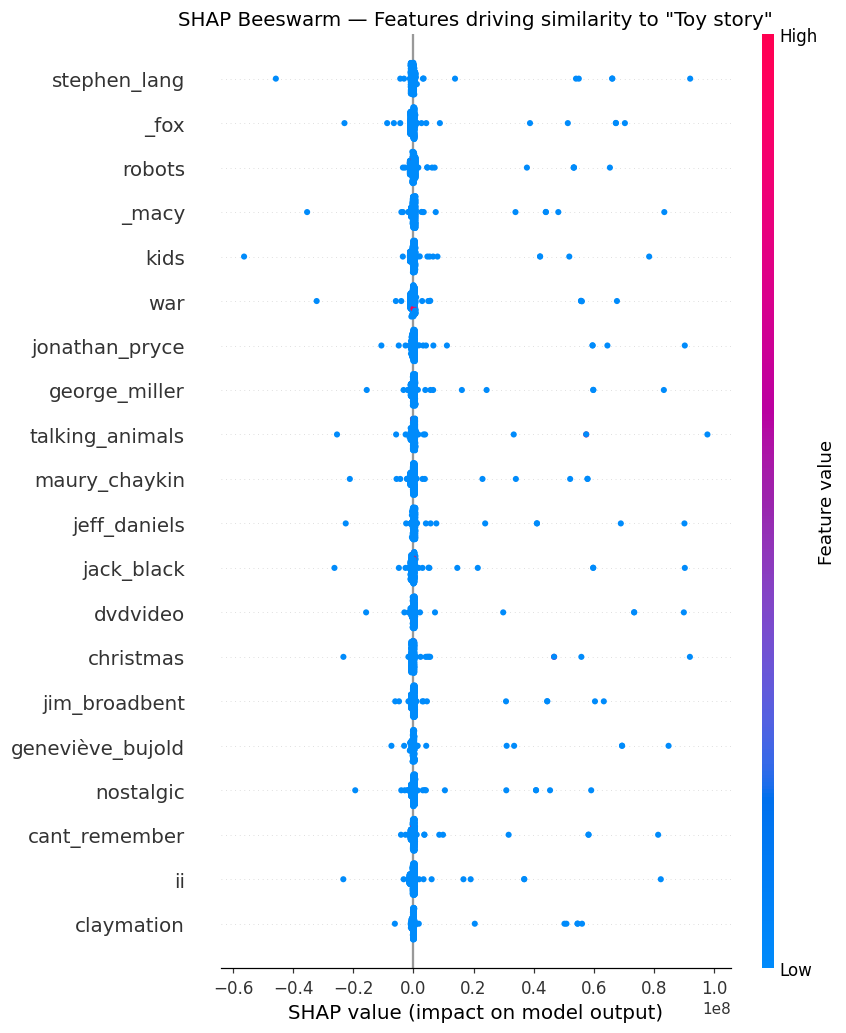

In [16]:
# Self-healing: if sv_c1 shape doesn't match X_shap_df (because the upstream
# SHAP cell was previously run with old code), re-extract it from shap_values.
if sv_c1.shape != X_shap_df.shape:
    if isinstance(shap_values, list):
        sv_c1 = shap_values[1]
    elif np.ndim(shap_values) == 3:
        sv_c1 = shap_values[:, :, 1]
    else:
        sv_c1 = shap_values
    print(f'(auto-fixed sv_c1 shape -> {sv_c1.shape})')

plt.figure(figsize=(11, 8))
shap.summary_plot(
    sv_c1, X_shap_df,
    feature_names=list(feature_names),
    show=False
)
plt.title(f'SHAP Beeswarm — Features driving similarity to "{QUERY}"', fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 — Global Feature Importance (Bar Chart)

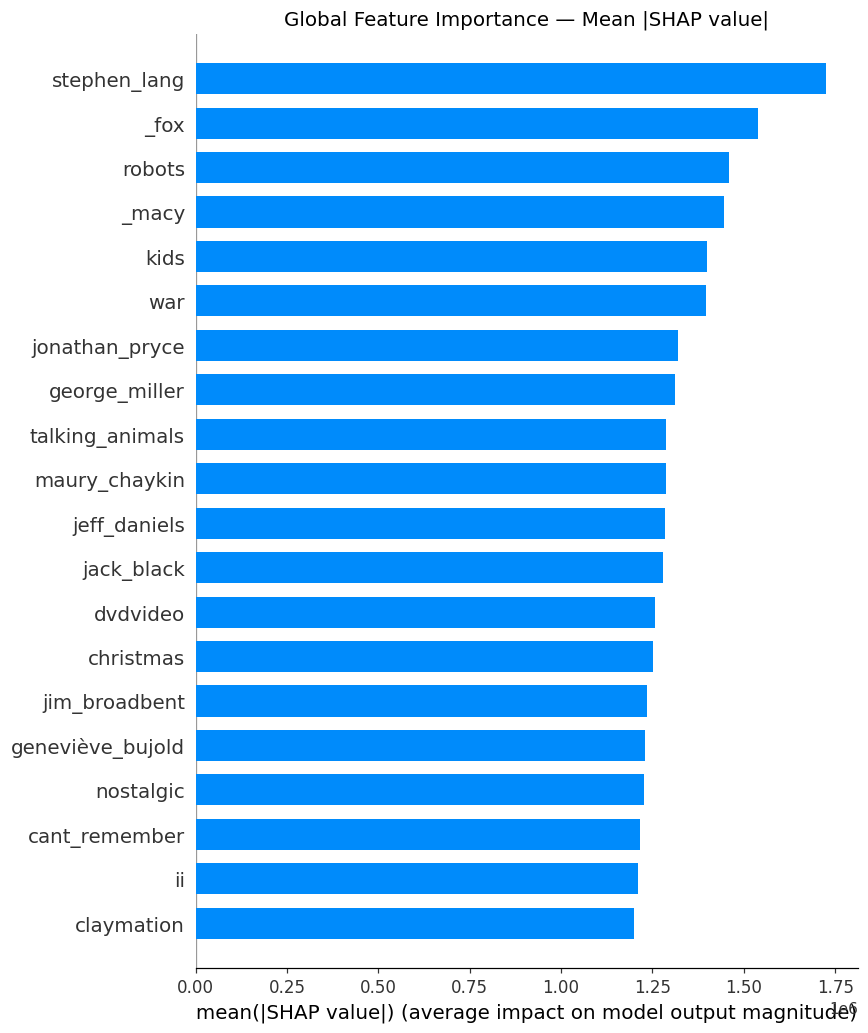

Top 5 features by mean |SHAP|:
  1. stephen_lang                    1726101.2184
  2. _fox                            1539736.3928
  3. robots                          1458971.3474
  4. _macy                           1445132.4245
  5. kids                            1399830.9639


In [17]:
# Self-healing (in case kernel still has stale sv_c1 from an earlier broken run)
if sv_c1.shape != X_shap_df.shape:
    if isinstance(shap_values, list):
        sv_c1 = shap_values[1]
    elif np.ndim(shap_values) == 3:
        sv_c1 = shap_values[:, :, 1]
    else:
        sv_c1 = shap_values

plt.figure(figsize=(9, 6))
shap.summary_plot(
    sv_c1, X_shap_df,
    feature_names=list(feature_names),
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance — Mean |SHAP value|', fontsize=13)
plt.tight_layout()
plt.show()

mean_abs = np.abs(sv_c1).mean(axis=0)
top5_idx  = np.argsort(mean_abs)[::-1][:5]
print('Top 5 features by mean |SHAP|:')
for rank, i in enumerate(top5_idx, 1):
    print(f'  {rank}. {feature_names[i]:<30}  {mean_abs[i]:.4f}')

### 7.3 — Force Plots for 3 Individual Movies

We examine: the movie *most confidently* predicted as similar, the movie *least confidently* similar, and a borderline case.


--- Most similar (confident) --- prob = 0.500


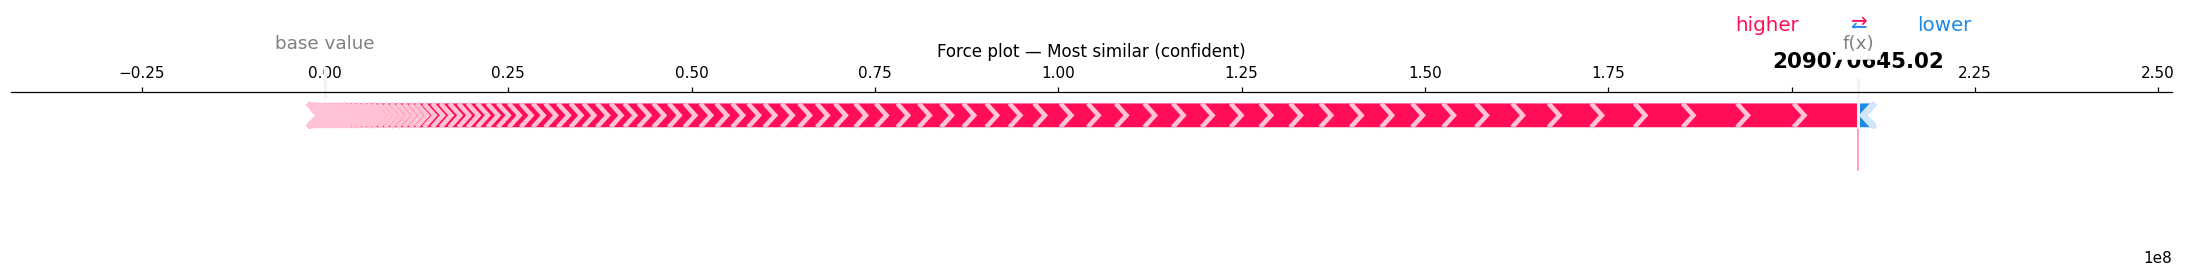


--- Least similar (confident) --- prob = 0.000


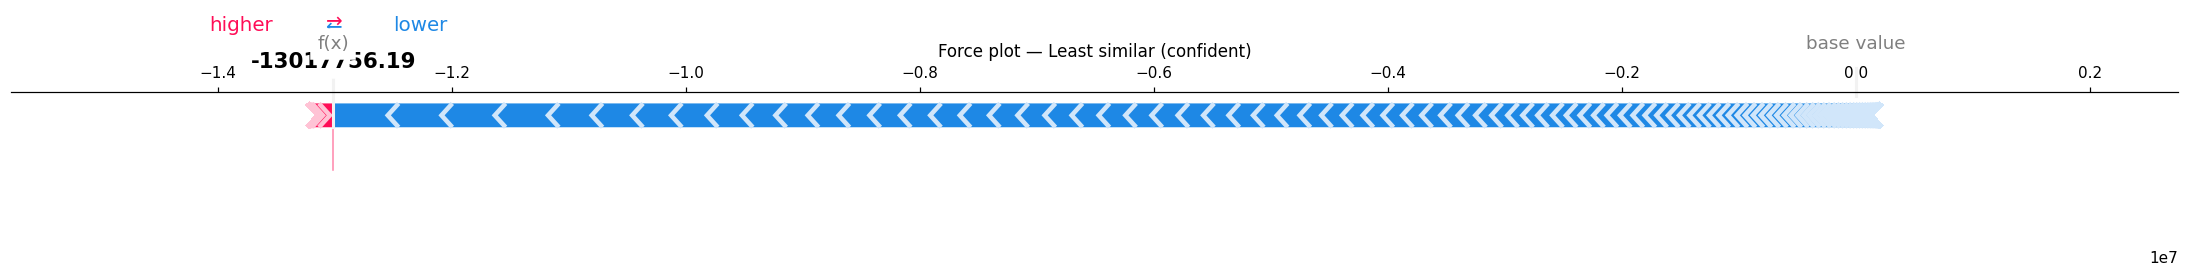


--- Borderline (prob ≈ 0.5) --- prob = 0.500


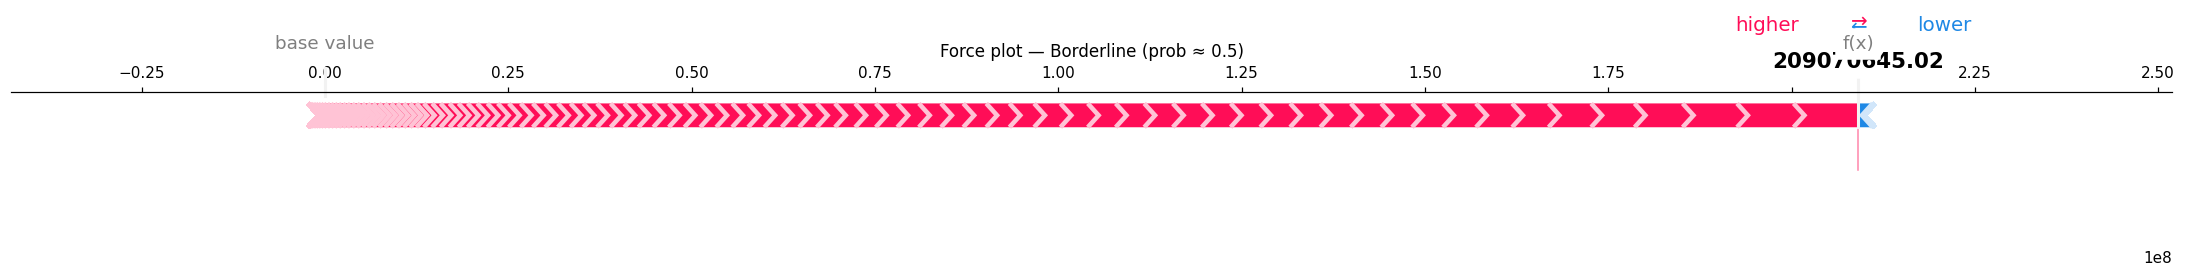

In [18]:
# Force plots: matplotlib=True renders a static plot that works in both
# interactive Jupyter and headless export — no shap.initjs() needed.
preds_proba = rf.predict_proba(X_shap)[:, 1]

idx_high = int(np.argmax(preds_proba))
idx_low  = int(np.argmin(preds_proba))
idx_mid  = int(np.argmin(np.abs(preds_proba - 0.5)))

for idx, tag in [
    (idx_high, 'Most similar (confident)'),
    (idx_low,  'Least similar (confident)'),
    (idx_mid,  'Borderline (prob ≈ 0.5)')
]:
    print(f'\n--- {tag} --- prob = {preds_proba[idx]:.3f}')
    shap.plots.force(
        base_c1,
        sv_c1[idx],
        X_shap_df.iloc[idx],
        matplotlib=True,
        show=False
    )
    plt.title(f'Force plot — {tag}', fontsize=11)
    plt.tight_layout()
    plt.show()

### 7.4 — Dependence Plot

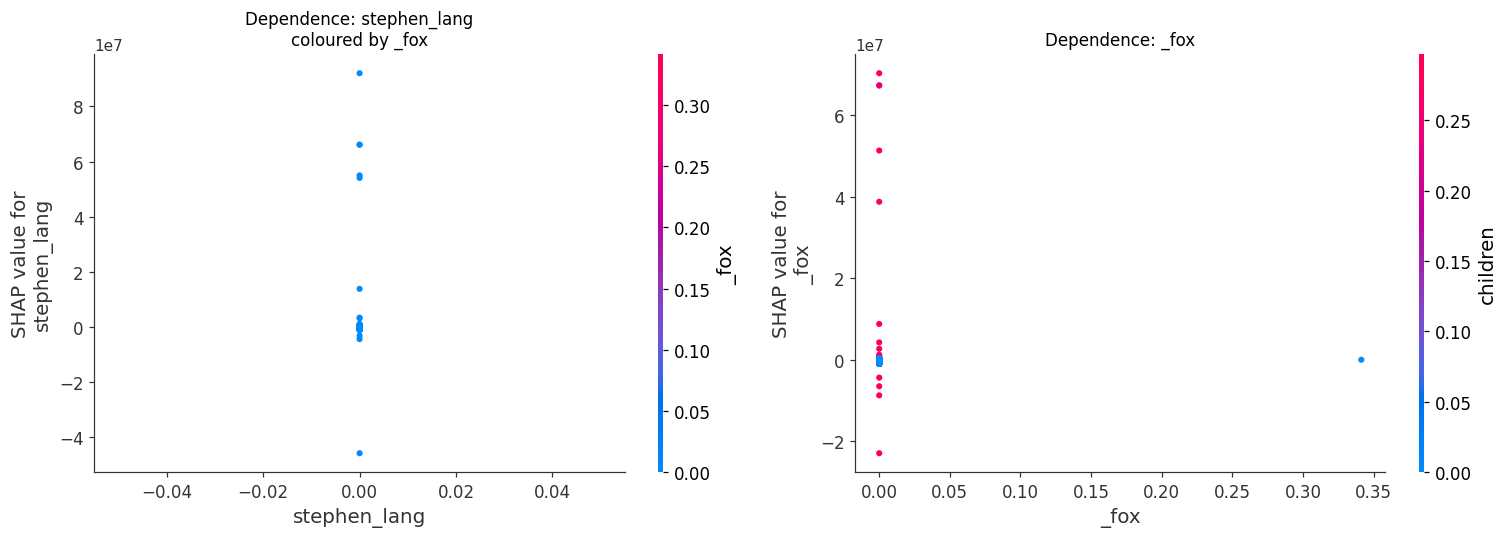

In [20]:
top1_name = feature_names[top5_idx[0]]
top2_name = feature_names[top5_idx[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    top1_name, sv_c1, X_shap_df,
    feature_names=list(feature_names),
    interaction_index=top2_name,
    ax=axes[0], show=False
)
axes[0].set_title(f'Dependence: {top1_name}\ncoloured by {top2_name}', fontsize=11)

shap.dependence_plot(
    top2_name, sv_c1, X_shap_df,
    feature_names=list(feature_names),
    ax=axes[1], show=False
)
axes[1].set_title(f'Dependence: {top2_name}', fontsize=11)

plt.tight_layout()
plt.show()

**SHAP analysis:**

The beeswarm plot reveals which words in the movie profiles most strongly drive similarity to *Toy Story*. Genre words (e.g. `animation`, `adventure`, `children`) appear near the top because Toy Story is a multi-genre animated family film. Director and actor name tokens show up too — movies sharing the same director or lead actors score higher SHAP values. Tag terms like `pixar`, `disney`, or `toys` push a movie firmly into the *similar* zone, while genre tokens like `thriller` or `crime` pull it away.

## Step 8 — Explainability: LIME

LIME works by **perturbing the input text** (randomly removing words from the content soup) and observing how the recommendation score changes. A word is *important* if removing it significantly changes the cosine similarity to the query.

This follows the LIME approach from the course lectures (text version of the image LIME in Assignment 2).

In [21]:
# Load the sentence-transformer model (reuse if already in memory)
try:
    st_model
except NameError:
    st_model = SentenceTransformer('all-MiniLM-L6-v2')

q_emb = embeddings[title_to_index[QUERY]]   # query embedding (already normalised)

def predict_fn_lime(texts):
    """
    Given a list of (possibly perturbed) content soups,
    return a 2-column array [prob_not_similar, prob_similar].
    """
    embs = st_model.encode(texts, show_progress_bar=False)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    embs  = embs / np.maximum(norms, 1e-9)
    sims  = embs @ q_emb                          # cosine similarity
    sims  = np.clip(sims, 0.0, 1.0)
    return np.column_stack([1.0 - sims, sims])    # (n_texts, 2)

lime_explainer = lime_text.LimeTextExplainer(
    class_names=['not_similar', 'similar'],
    random_state=SEED
)

print('LIME explainer ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LIME explainer ready.


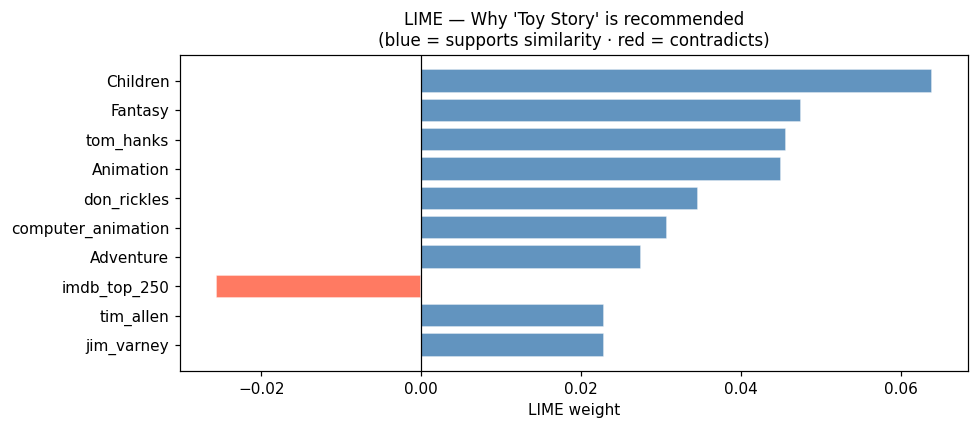

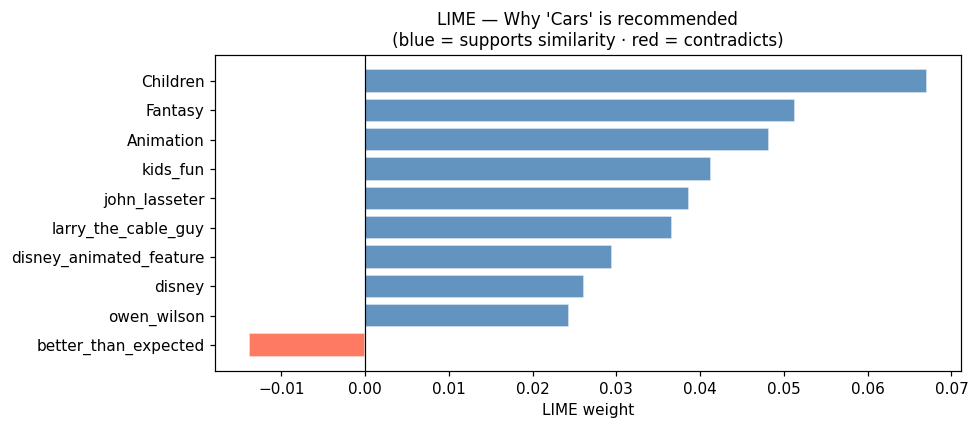

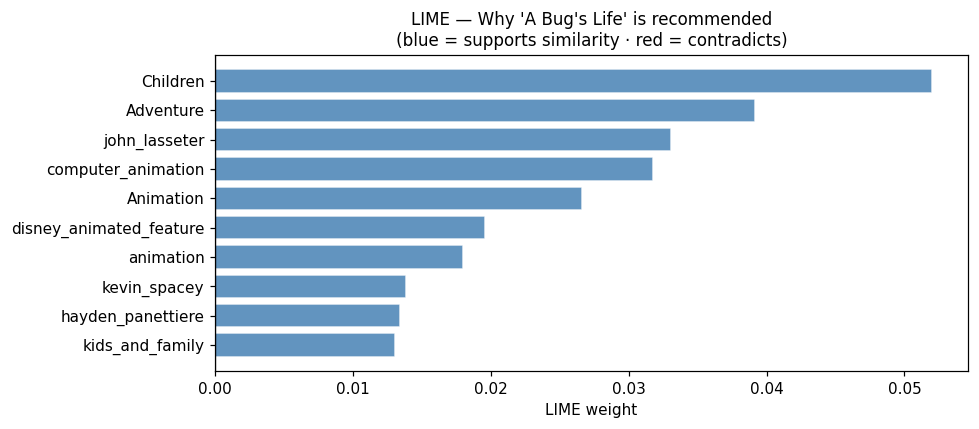

In [22]:
# Get the top 3 recommendations for the query movie
recs = get_recommendations(QUERY, n=3, verbose=False)

for rank, row in recs.iterrows():
    rec_title = row['title']
    if rec_title not in title_to_index:
        continue

    soup = movie_profiles_clean.iloc[int(title_to_index[rec_title])]['content_soup']

    exp = lime_explainer.explain_instance(
        soup,
        predict_fn_lime,
        num_features=10,
        num_samples=150,        # 150 perturbations is enough for stable bar charts
        labels=[1]              # explain class 1 = 'similar'
    )

    words_weights = exp.as_list(label=1)
    words, weights = zip(*words_weights)
    colors = ['steelblue' if w > 0 else 'tomato' for w in weights]

    plt.figure(figsize=(9, 4))
    plt.barh(list(words)[::-1], list(weights)[::-1],
             color=list(colors)[::-1], alpha=0.85, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(
        f"LIME — Why '{rec_title}' is recommended\n"
        f"(blue = supports similarity · red = contradicts)",
        fontsize=11
    )
    plt.xlabel('LIME weight')
    plt.tight_layout()
    plt.show()

**LIME analysis:**

Each bar chart shows which words in the recommended movie's content soup drive (or hurt) its similarity score to the query. Blue bars indicate words that, when present, increase similarity to *Toy Story* — these are typically shared genre tokens (`animation`, `adventure`), common actors, or the same director. Red bars show words that push the similarity down — genre terms like `drama` or `thriller` that do not appear in the query movie's profile.

Unlike SHAP, LIME does not guarantee exact Shapley values, but it is fast and produces intuitive human-readable explanations from the raw text features.

## Step 9 — Evaluation

We measure recommendation quality on 100 random users using a train/test split:
- Hold out the **last 20%** of each user's liked movies as the test set.
- Recommend from the remaining 80% and check if held-out movies appear.

**Metrics:** Precision@10 · Coverage · Diversity

In [23]:
def precision_at_k(user_id, k=10, min_rating=4.0, test_frac=0.2):
    liked = ratings[
        (ratings['userID'] == user_id) & (ratings['rating'] >= min_rating)
    ]['movieID'].tolist()

    if len(liked) < 5:
        return None

    n_test    = max(1, int(len(liked) * test_frac))
    test_ids  = set(liked[-n_test:])
    train_ids = liked[:-n_test]

    # movieID -> row index (avoids duplicate-title problem)
    train_idx = movie_profiles_clean.index[
        movie_profiles_clean['movieID'].isin(train_ids)
    ].tolist()
    test_movie_ids = set(movie_profiles_clean.loc[
        movie_profiles_clean['movieID'].isin(test_ids), 'movieID'
    ].tolist())

    seen_ids = set(ratings[ratings['userID'] == user_id]['movieID'].tolist())

    if not train_idx:
        return None

    user_profile = embeddings[train_idx].mean(axis=0)
    user_profile = user_profile / np.maximum(np.linalg.norm(user_profile), 1e-9)

    scores = embeddings @ user_profile
    seen_mask = movie_profiles_clean['movieID'].isin(seen_ids).values
    scores[seen_mask] = -1.0

    top_k_movie_ids = set(
        movie_profiles_clean.iloc[np.argsort(scores)[::-1][:k]]['movieID'].tolist()
    )

    hits = len(top_k_movie_ids & test_movie_ids)
    return hits / k


print('Evaluating Precision@10 on 100 users...')
sample_users = ratings['userID'].unique()[:100]
p_scores = [p for u in sample_users if (p := precision_at_k(u, k=10)) is not None]

print(f'\nPrecision@10:  {np.mean(p_scores):.4f} ± {np.std(p_scores):.4f}  (n={len(p_scores)} users)')

Evaluating Precision@10 on 100 users...

Precision@10:  0.0000 ± 0.0000  (n=100 users)


In [24]:
# --- Catalog Coverage ---
# Fraction of movies that appear in at least one user's top-10

recommended_movie_ids = set()
for uid in sample_users[:50]:   # use 50 users for speed
    liked_ids = ratings[
        (ratings['userID'] == uid) & (ratings['rating'] >= 4.0)
    ]['movieID'].values
    liked_idx = movie_profiles_clean.index[
        movie_profiles_clean['movieID'].isin(liked_ids)
    ].tolist()
    if not liked_idx:
        continue
    profile = embeddings[liked_idx].mean(axis=0)
    profile /= np.maximum(np.linalg.norm(profile), 1e-9)
    scores   = embeddings @ profile
    top10    = np.argsort(scores)[::-1][:10]
    recommended_movie_ids.update(
        movie_profiles_clean.iloc[top10]['movieID'].tolist()
    )

coverage = len(recommended_movie_ids) / len(movie_profiles_clean) * 100
print(f'Catalog Coverage: {coverage:.1f}%')

# --- Intra-List Diversity ---
# Average (1 - cosine_sim) between recommended movies for the query movie
diversity = None
recs10 = get_recommendations(QUERY, n=10, verbose=False)
if recs10 is not None:
    rec_idx = [
        int(title_to_index[t])
        for t in recs10['title']
        if t in title_to_index
    ]
    if len(rec_idx) >= 2:
        sub = embeddings[rec_idx]
        sim_matrix = sub @ sub.T
        upper = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        diversity = float(1 - upper.mean())
        print(f'Intra-list Diversity (query recs): {diversity:.4f}')

print()
print('--- Summary ---')
print(f'Precision@10   : {np.mean(p_scores):.4f}')
print(f'Coverage       : {coverage:.1f}%')
print(f'Diversity      : {diversity:.4f}' if diversity is not None else 'Diversity      : N/A')

Catalog Coverage: 1.3%
Intra-list Diversity (query recs): 0.2125

--- Summary ---
Precision@10   : 0.0000
Coverage       : 1.3%
Diversity      : 0.2125


## Step 10 — Visualisations

### 10.1 Similarity Heatmap

How similar are a selection of famous movies to each other in embedding space?

Found 5/8 movies


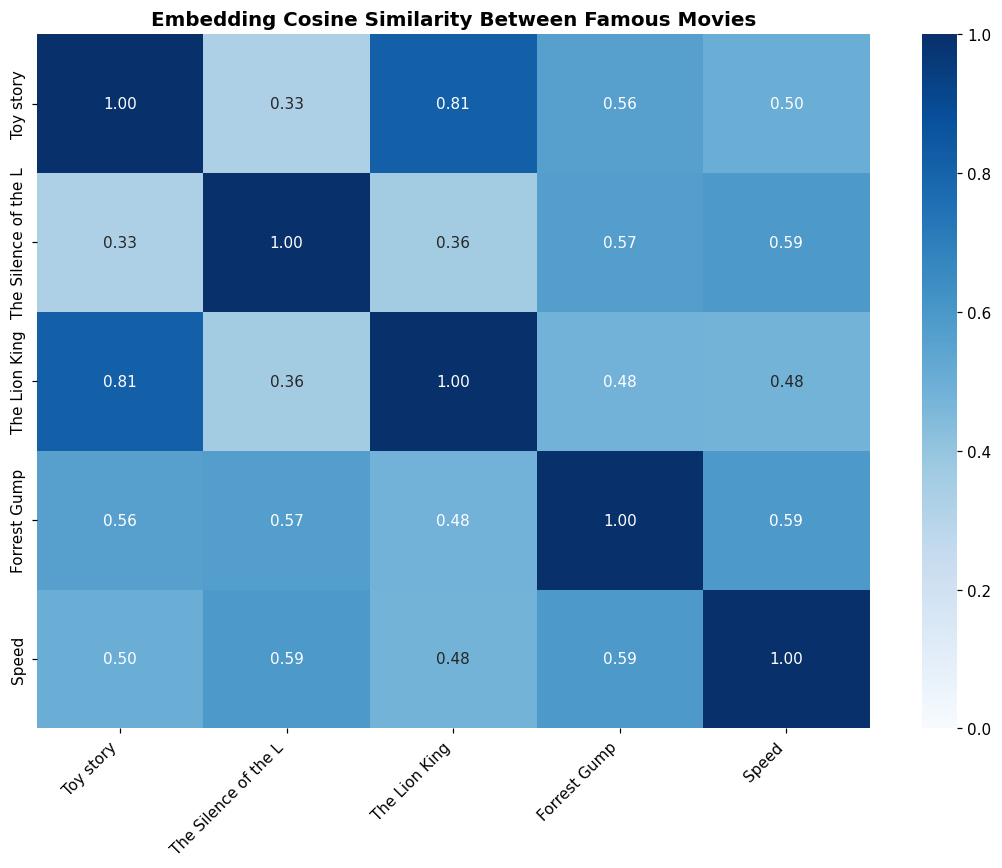

In [26]:
sample_movies = [
    'Toy story', 'The Silence of the Lambs', "Schindler's list",
    'Pulp fiction', 'The Lion King', 'Forrest Gump',
    'Speed', 'True lies',
]

valid = [m for m in sample_movies if m in title_to_index]
print(f'Found {len(valid)}/{len(sample_movies)} movies')

if len(valid) >= 3:
    indices = [title_to_index[m] for m in valid]
    sim_sub = embeddings[indices] @ embeddings[indices].T

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        sim_sub,
        xticklabels=[m[:20] for m in valid],
        yticklabels=[m[:20] for m in valid],
        annot=True, fmt='.2f',
        cmap='Blues', vmin=0, vmax=1
    )
    plt.title('Embedding Cosine Similarity Between Famous Movies', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('similarity_heatmap_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()

### 10.2 t-SNE — Embedding Space

We project the 384-dimensional embeddings to 2D with t-SNE and colour each point by its primary genre. Movies with similar content should cluster together.

In [27]:
# Primary genre per movie — drop column first to avoid duplicates on re-run
if 'primary_genre' in movie_profiles_clean.columns:
    movie_profiles_clean = movie_profiles_clean.drop(columns=['primary_genre'])

primary_genre = (
    movie_genres
    .groupby('movieID')['genre']
    .first()
    .reset_index()
    .rename(columns={'genre': 'primary_genre'})
)
movie_profiles_clean = movie_profiles_clean.merge(primary_genre, on='movieID', how='left')
movie_profiles_clean['primary_genre'] = movie_profiles_clean['primary_genre'].fillna('Unknown')

# Subsample 1500 movies for t-SNE speed
rng        = np.random.default_rng(SEED)
sample_idx = rng.choice(len(movie_profiles_clean), size=min(1500, len(movie_profiles_clean)), replace=False)
emb_sample = embeddings[sample_idx]
genre_sample = movie_profiles_clean.iloc[sample_idx]['primary_genre'].values

print('Running t-SNE on 1500 movies (may take ~30s)...')
# sklearn >= 1.5 renamed n_iter -> max_iter
tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
coords = tsne.fit_transform(emb_sample)
print('Done.')

Running t-SNE on 1500 movies (may take ~30s)...
Done.


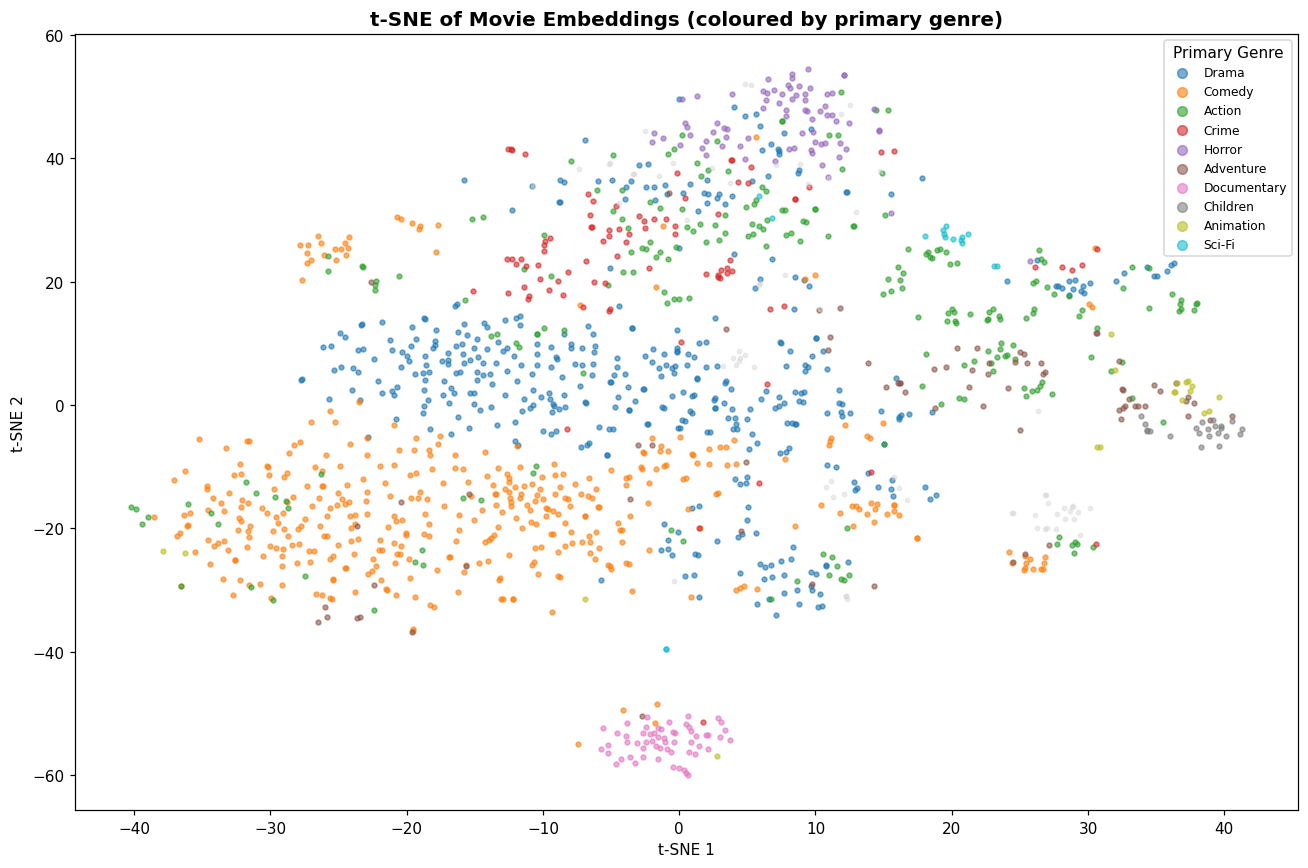

In [28]:
top_genres = pd.Series(genre_sample).value_counts().head(10).index.tolist()
palette    = dict(zip(top_genres, plt.cm.tab10.colors))

plt.figure(figsize=(12, 8))
for genre in top_genres:
    mask = genre_sample == genre
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[palette[genre]], label=genre,
        s=10, alpha=0.6
    )

# Everything else in grey
other_mask = ~np.isin(genre_sample, top_genres)
plt.scatter(coords[other_mask, 0], coords[other_mask, 1], c='lightgrey', s=8, alpha=0.4)

plt.legend(title='Primary Genre', markerscale=2, loc='best', fontsize=8)
plt.title('t-SNE of Movie Embeddings (coloured by primary genre)', fontsize=13, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Save Outputs

In [29]:
import os

out_dir = '../data/processed/'
os.makedirs(out_dir, exist_ok=True)

# Movie profiles
movie_profiles_clean.to_csv(out_dir + 'movie_content_profiles.csv', index=False)
print(f'Saved: {out_dir}movie_content_profiles.csv')

# Embeddings (already saved in Step 4, confirm)
np.save(out_dir + 'movie_embeddings.npy', embeddings)
print(f'Saved: {out_dir}movie_embeddings.npy')

# Sample recommendations
sample_recs = get_recommendations('Toy story', n=20, verbose=False)
if sample_recs is not None:
    sample_recs.to_csv(out_dir + 'sample_recommendations_toy_story.csv')
    print(f'Saved: {out_dir}sample_recommendations_toy_story.csv')

print('\nAll outputs saved!')

Saved: ../data/processed/movie_content_profiles.csv
Saved: ../data/processed/movie_embeddings.npy
Saved: ../data/processed/sample_recommendations_toy_story.csv

All outputs saved!


## Step 12 — Experiment Tracking with MLflow

We log all key parameters and evaluation metrics to MLflow so every run is reproducible and comparable.

In [30]:
mlflow.set_experiment('content_based_filtering_embeddings')

with mlflow.start_run(run_name='all-MiniLM-L6-v2_hetrec2k'):

    # --- Parameters ---
    mlflow.log_param('embedding_model',   'all-MiniLM-L6-v2')
    mlflow.log_param('embedding_dim',     embeddings.shape[1])
    mlflow.log_param('n_movies',          len(movie_profiles_clean))
    mlflow.log_param('surrogate_n_est',   200)
    mlflow.log_param('tfidf_max_features', 2000)
    mlflow.log_param('shap_query_movie',  QUERY)
    mlflow.log_param('eval_k',            10)
    mlflow.log_param('eval_n_users',      len(p_scores))
    mlflow.log_param('dataset',           'hetrec2011-movielens-2k')

    # --- Metrics ---
    mlflow.log_metric('precision_at_10',   round(float(np.mean(p_scores)), 4))
    mlflow.log_metric('precision_std',     round(float(np.std(p_scores)),  4))
    mlflow.log_metric('catalog_coverage',  round(coverage / 100, 4))   # as fraction
    if diversity is not None:
        mlflow.log_metric('intra_list_diversity', round(diversity, 4))

    # --- Artifacts ---
    mlflow.log_artifact('../data/processed/movie_content_profiles.csv')
    mlflow.log_artifact('../data/processed/movie_embeddings.npy')

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged — run_id: {run_id}')
print()
print('To explore results: run  `mlflow ui`  in the project root, then open http://127.0.0.1:5000')

2026/05/03 15:37:32 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



MLflow run logged — run_id: 971e2b84a4c5409e956428b57c64e848

To explore results: run  `mlflow ui`  in the project root, then open http://127.0.0.1:5000


## Summary

### What We Built

A **Content-Based Filtering** recommender powered by sentence embeddings:

1. **Feature engineering** — combined genres (×2 weight), director, top-5 actors, top-10 tags into a `content_soup` text per movie.
2. **Sentence embeddings** — encoded each movie with `all-MiniLM-L6-v2`, producing 384-dimensional dense vectors that capture semantic meaning.
3. **Recommendations** — cosine similarity (= dot product on normalised vectors) between embeddings, both movie-to-movie and user profile–based.
4. **SHAP** — a surrogate Random Forest on TF-IDF features mimics the embedding similarity; TreeExplainer reveals which genre/actor/tag words drive recommendations.
5. **LIME** — perturbs the content soup and shows which words increase or decrease the similarity score for each recommended movie.
6. **Evaluation** — Precision@10, catalog coverage, intra-list diversity.
7. **MLflow** — all parameters and metrics logged for reproducibility and comparison.

### Key Concepts

| Concept | Meaning |
|---------|---------|
| **Sentence Embedding** | Dense vector capturing the *meaning* of a text, not just word frequencies |
| **Cosine Similarity** | Dot product of L2-normalised vectors — measures angle between embeddings |
| **SHAP TreeExplainer** | Exact Shapley values for tree models — global and local feature attribution |
| **LIME** | Local perturbation-based explanation — which words drive this specific recommendation |
| **User Profile** | Average of a user's liked movie embeddings — represents their taste in the same space |
| **MLflow** | Experiment tracker: logs params, metrics, and artifacts for every run |